<a href="https://colab.research.google.com/github/niyasnasmal8-jpg/ict_assignments/blob/main/Assignment_classification03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1.

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/bank-additional-full.csv")

# View data
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [2]:
# Structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [3]:
# Numerical & categorical columns
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:\n", num_cols)
print("Categorical Columns:\n", cat_cols)

Numerical Columns:
 Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')
Categorical Columns:
 Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')


In [4]:
# Target distribution
df['y'].value_counts()

,count
y,
no,36548
yes,4640


#2.

In [5]:
import numpy as np

df = df.replace('unknown', np.nan)

# Fill missing values
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_2001/1456250242.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_2001/1456250242.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [7]:
X = df.drop('y', axis=1)
y = df['y']


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#3.

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(y_test, y_pred):
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("-"*30)

In [11]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)
evaluate(y_test, lr.predict(X_test))

Accuracy: 0.9102937606215101
Precision: 0.6678082191780822
Recall: 0.41711229946524064
F1 Score: 0.5134957208689928
------------------------------


In [12]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
evaluate(y_test, knn.predict(X_test))

Accuracy: 0.8982762806506434
Precision: 0.5754276827371695
Recall: 0.39572192513368987
F1 Score: 0.46894803548795944
------------------------------


In [13]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train, y_train)
evaluate(y_test, svm.predict(X_test))

Accuracy: 0.9085943190094683
Precision: 0.6654545454545454
Recall: 0.39144385026737966
F1 Score: 0.49292929292929294
------------------------------


In [14]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
evaluate(y_test, dt.predict(X_test))

Accuracy: 0.8860160233066279
Precision: 0.4979209979209979
Recall: 0.5122994652406417
F1 Score: 0.5050079072219293
------------------------------


#4.

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
evaluate(y_test, rf.predict(X_test))

Accuracy: 0.9155134741442098
Precision: 0.6558018252933507
Recall: 0.5379679144385027
F1 Score: 0.5910693301997649
------------------------------


In [16]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)
evaluate(y_test, gb.predict(X_test))

Accuracy: 0.9208545763534839
Precision: 0.6968011126564673
Recall: 0.5358288770053476
F1 Score: 0.6058041112454655
------------------------------


#5.

In [17]:
models = {
    "Logistic": lr,
    "KNN": knn,
    "SVM": svm,
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ])

result_df = pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","F1"])
result_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic,0.910294,0.667808,0.417112,0.513496
1,KNN,0.898276,0.575428,0.395722,0.468948
2,SVM,0.908594,0.665455,0.391444,0.492929
3,Decision Tree,0.886016,0.497921,0.512299,0.505008
4,Random Forest,0.915513,0.655802,0.537968,0.591069
5,Gradient Boosting,0.920855,0.696801,0.535829,0.605804


#6.

In [18]:
best_model = result_df.sort_values(by="F1", ascending=False)
best_model

,Model,Accuracy,Precision,Recall,F1
5,Gradient Boosting,0.920855,0.696801,0.535829,0.605804
4,Random Forest,0.915513,0.655802,0.537968,0.591069
0,Logistic,0.910294,0.667808,0.417112,0.513496
3,Decision Tree,0.886016,0.497921,0.512299,0.505008
2,SVM,0.908594,0.665455,0.391444,0.492929
1,KNN,0.898276,0.575428,0.395722,0.468948


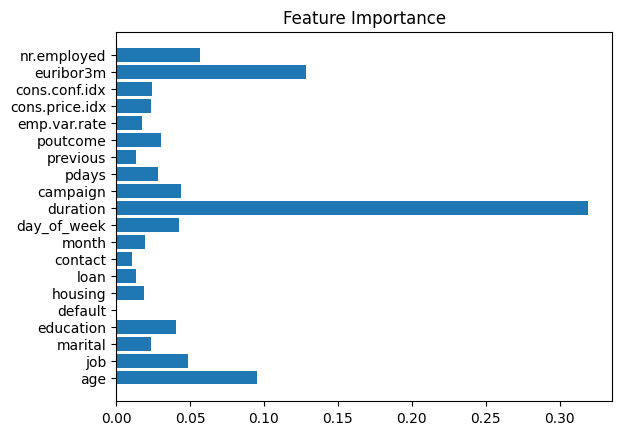

In [19]:
import matplotlib.pyplot as plt

importance = rf.feature_importances_
features = X.columns

plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()